# Train Face Mask Detection

Notebook ini buat training YOLO26m yang nge-deteksi wajah jadi 3 kelas:

- `0 = improper_mask` — pakai masker tapi nggak benar (turun di dagu, dst.)
- `1 = mask` — pakai masker dengan benar
- `2 = no_mask` — nggak pakai masker

**Dataset:** `research/datasets/interim/face_mask_cctv_split/` — sudah ke-split jadi train/valid/test.

**Output:** `best.pt` di `research/runs/detect/face_mask_yolo26m/weights/`. Habis ini bisa di-register di [registry.py](../../../src/cctv_insight_ai/models/registry.py).

## Alur

1. Setup
2. Cek dataset
3. Training
4. Load run terakhir
5. Evaluasi
6. Visualisasi (training curves, per-class, confusion matrix, sample prediksi)


In [1]:
%matplotlib inline

from __future__ import annotations

import contextlib
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from PIL import Image
from ultralytics import YOLO

NOTEBOOK_DIR = Path.cwd()
RESEARCH_DIR = NOTEBOOK_DIR.parents[1]
AI_DIR       = NOTEBOOK_DIR.parents[2]

DATASET_DIR  = RESEARCH_DIR / "datasets" / "interim" / "face_mask_cctv_split"
DATA_YAML    = DATASET_DIR / "data.yaml"
BASE_MODEL   = AI_DIR / "models" / "yolo26m.pt"

RUNS_DIR      = RESEARCH_DIR / "runs" / "detect"
ARTIFACTS_DIR = RESEARCH_DIR / "artifacts" / "face_mask"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = "face_mask_yolo26m"
SEED     = 42

for p in [DATA_YAML, BASE_MODEL]:
    if not p.exists():
        raise FileNotFoundError(f"Nggak ketemu: {p}")
print("Dataset:", DATASET_DIR)
print("Base model:", BASE_MODEL)

Dataset: c:\Users\istd.magang125\Documents\cctv-insight\ai\research\datasets\interim\face_mask_cctv_split
Base model: c:\Users\istd.magang125\Documents\cctv-insight\ai\models\yolo26m.pt


## Cek Dataset

Lihat distribusi label per kelas per split. Kalau ada split yang imbalanced banget, bisa jadi sumber bias.


In [2]:
def count_class_distribution(split: str) -> dict[int, int]:
    counts: dict[int, int] = {0: 0, 1: 0, 2: 0}
    labels_dir = DATASET_DIR / split / "labels"
    if not labels_dir.exists():
        return counts
    for lbl in labels_dir.glob("*.txt"):
        for line in lbl.read_text().splitlines():
            line = line.strip()
            if not line:
                continue
            cls = int(line.split()[0])
            counts[cls] = counts.get(cls, 0) + 1
    return counts


cfg = yaml.safe_load(DATA_YAML.read_text(encoding="utf-8"))
class_names = cfg["names"]
print("Kelas:", class_names)

dist = {split: count_class_distribution(split) for split in ("train", "valid", "test")}
dist_df = pd.DataFrame(dist).fillna(0).astype(int)
dist_df.index = [class_names[i] for i in dist_df.index]
print()
print(dist_df.to_string())

Kelas: ['Improper Mask', 'Mask', 'No Mask']

               train  valid  test
Improper Mask   2393    663   318
Mask            1833    539   264
No Mask         1804    513   260


## Training

Set `RUN_TRAINING = True` kalau emang mau training ulang. Default `False` biar nggak ke-trigger pas re-run notebook.

Default 50 epoch, patience 20 (auto-stop kalau val loss nggak turun selama 20 epoch). Ubah di `TRAIN_CFG` kalau perlu.


In [3]:
RUN_TRAINING = False

TRAIN_CFG = {
    "epochs": 50,
    "imgsz": 640,
    "batch": 8,
    "workers": 4,
    "patience": 20,
    "seed": SEED,
    "project": str(RUNS_DIR),
    "name": RUN_NAME,
}


@contextlib.contextmanager
def _cwd(path):
    prev = os.getcwd()
    os.chdir(str(path))
    try:
        yield
    finally:
        os.chdir(prev)


if RUN_TRAINING:
    with _cwd(AI_DIR / "models"):
        model = YOLO(str(BASE_MODEL))
        result = model.train(data=str(DATA_YAML), **TRAIN_CFG)
    print("Training kelar:", result.save_dir)
else:
    print("Training di-skip. Set RUN_TRAINING=True kalau mau training ulang.")

Training di-skip. Set RUN_TRAINING=True kalau mau training ulang.


## Load Run Terakhir

Cari folder run paling baru yang prefix-nya `face_mask_yolo26m`, ambil `best.pt`-nya buat di-eval.


In [4]:
def find_latest_run(prefix: str) -> Path:
    candidates = [
        d for d in RUNS_DIR.glob(f"{prefix}*")
        if d.is_dir() and (d / "weights" / "best.pt").exists()
    ]
    if not candidates:
        raise FileNotFoundError(f"Belum ada run dengan prefix '{prefix}' di {RUNS_DIR}")
    return max(candidates, key=lambda d: d.stat().st_mtime)


run_dir     = find_latest_run(RUN_NAME)
best_pt     = run_dir / "weights" / "best.pt"
results_csv = run_dir / "results.csv"
eval_model  = YOLO(str(best_pt))

print("Run dir:", run_dir)
print("Best weights:", best_pt)
print("Kelas:", eval_model.names)

Run dir: c:\Users\istd.magang125\Documents\cctv-insight\ai\research\runs\detect\face_mask_yolo26m
Best weights: c:\Users\istd.magang125\Documents\cctv-insight\ai\research\runs\detect\face_mask_yolo26m\weights\best.pt
Kelas: {0: 'Improper Mask', 1: 'Mask', 2: 'No Mask'}


## Evaluasi

Run `model.val()` di split valid. Yang dilihat: mAP50 (lenient), mAP50-95 (strict), Precision (false positive control), Recall (false negative control).


In [5]:
val = eval_model.val(data=str(DATA_YAML), imgsz=640, conf=0.25, verbose=False)

metrics = {
    "mAP50":     round(float(val.box.map50), 3),
    "mAP50-95":  round(float(val.box.map),   3),
    "Precision": round(float(val.box.mp),    3),
    "Recall":    round(float(val.box.mr),    3),
}
print("Metrik agregat:")
print(pd.DataFrame([metrics]).to_string(index=False))

Ultralytics 8.4.38  Python-3.14.3 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO26m summary (fused): 132 layers, 20,351,765 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 2787.4655.6 MB/s, size: 404.1 KB)
val: Scanning C:\Users\istd.magang125\Documents\cctv-insight\ai\research\datasets\interim\face_mask_cctv_split\valid\labels.cache... 349 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 349/349 86.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 5.4it/s 4.1s0.2s
                   all        349       1715      0.865       0.83       0.83      0.398
Speed: 0.6ms preprocess, 8.7ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to C:\Users\istd.magang125\Documents\backend\runs\detect\val18
Metrik agregat:
 mAP50  mAP50-95  Precision  Recall
  0.83     0.398      0.865    0.83


## Visualisasi

Empat hal yang paling kepake buat liat performa:

1. **Training curves** — apakah training konvergen, atau masih bisa lebih baik kalau lanjut.
2. **Per-class metrics** — kelas mana yang lemah.
3. **Confusion matrix** — kelas mana yang sering ke-tukar.
4. **Sample prediksi** — sanity check di image asli.


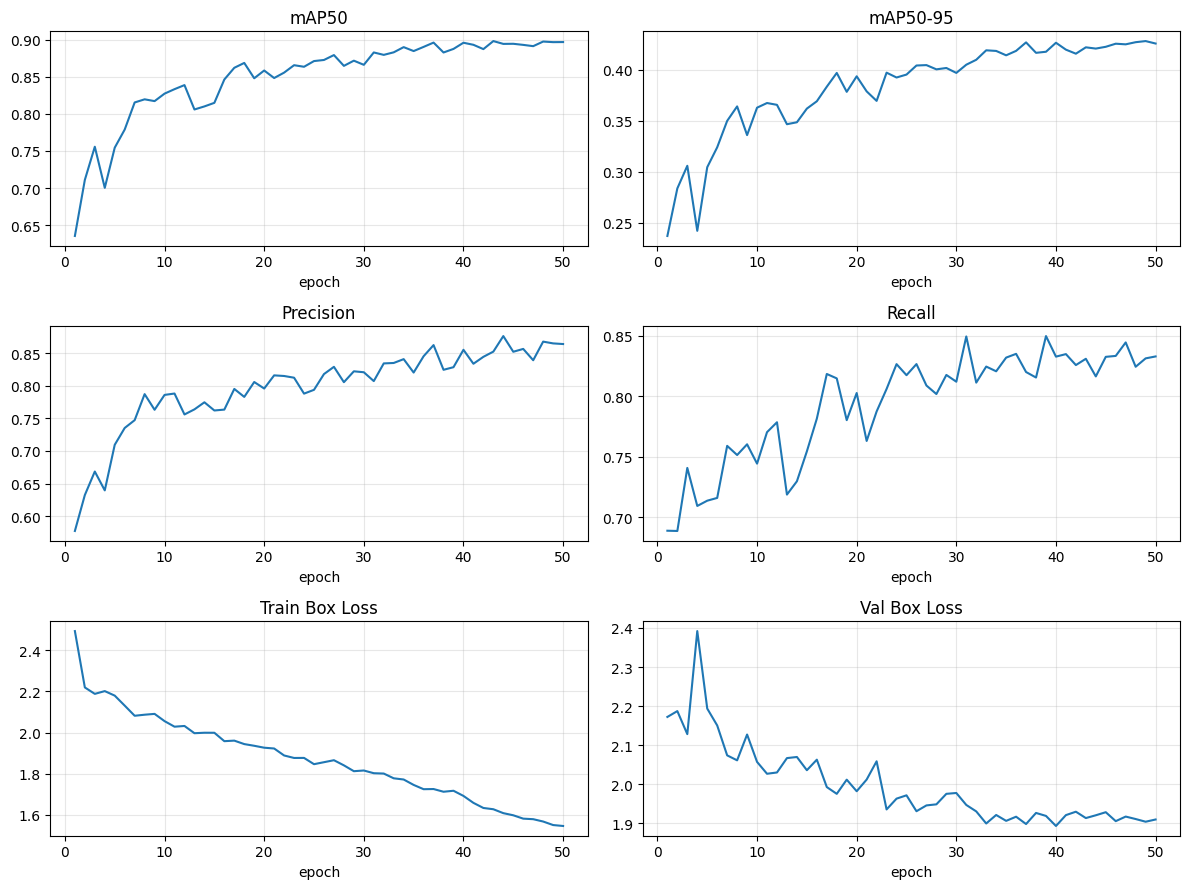

In [6]:
df = pd.read_csv(results_csv)
df.columns = [c.strip() for c in df.columns]

curves = [
    ("metrics/mAP50(B)",     "mAP50"),
    ("metrics/mAP50-95(B)",  "mAP50-95"),
    ("metrics/precision(B)", "Precision"),
    ("metrics/recall(B)",    "Recall"),
    ("train/box_loss",       "Train Box Loss"),
    ("val/box_loss",         "Val Box Loss"),
]
available = [(c, label) for c, label in curves if c in df.columns]
rows_n = (len(available) + 1) // 2
fig, axes = plt.subplots(rows_n, 2, figsize=(12, 3 * rows_n))
axes = axes.flatten()
for ax, (col, label) in zip(axes, available):
    ax.plot(df["epoch"], df[col])
    ax.set_title(label)
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)
for ax in axes[len(available):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

Per-class metrics:
        class  Precision  Recall  mAP50  mAP50-95
Improper Mask      0.849   0.839  0.834     0.424
         Mask      0.859   0.791  0.797     0.393
      No Mask      0.887   0.862  0.859     0.378


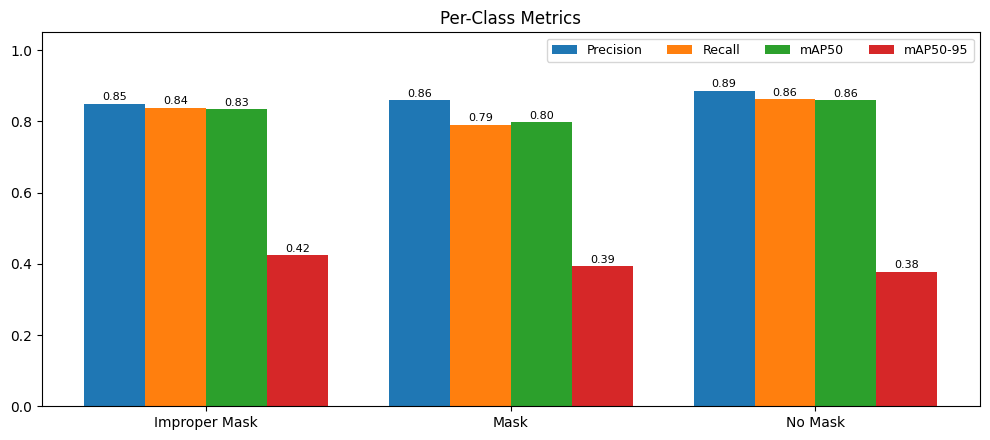

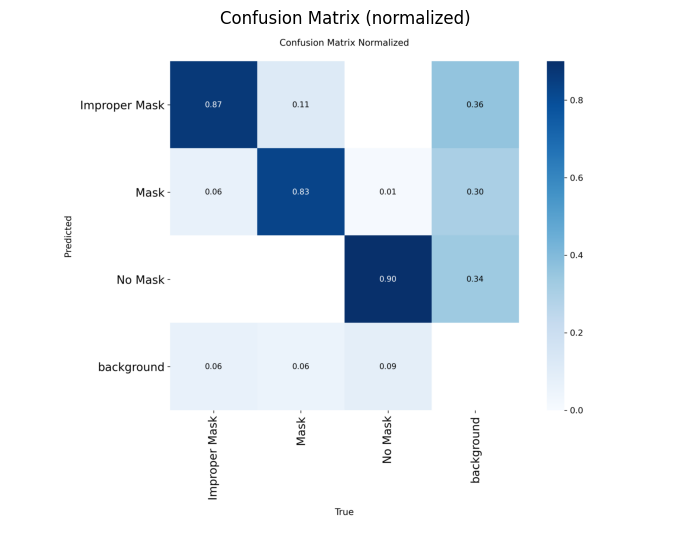

In [7]:
class_indices = val.box.ap_class_index.astype(int).tolist()
per_class = []
for i, ci in enumerate(class_indices):
    p, r, ap50, ap = val.box.class_result(i)
    per_class.append({
        "class":     val.names[ci],
        "Precision": float(p),
        "Recall":    float(r),
        "mAP50":     float(ap50),
        "mAP50-95":  float(ap),
    })
per_class_df = pd.DataFrame(per_class)
print("Per-class metrics:")
print(per_class_df.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4.5))
to_plot = ["Precision", "Recall", "mAP50", "mAP50-95"]
x = list(range(len(per_class_df)))
width = 0.2
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
for j, m in enumerate(to_plot):
    offset = (j - 1.5) * width
    bars = ax.bar([xi + offset for xi in x], per_class_df[m], width, label=m, color=colors[j])
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
                f"{b.get_height():.2f}", ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(per_class_df["class"])
ax.set_ylim(0, 1.05)
ax.set_title("Per-Class Metrics")
ax.legend(loc="upper right", ncol=4, fontsize=9)
plt.tight_layout()
plt.show()

cm_path = Path(val.save_dir) / "confusion_matrix_normalized.png"
if cm_path.exists():
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.imshow(Image.open(cm_path))
    ax.set_title("Confusion Matrix (normalized)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Confusion matrix nggak ketemu di:", cm_path)

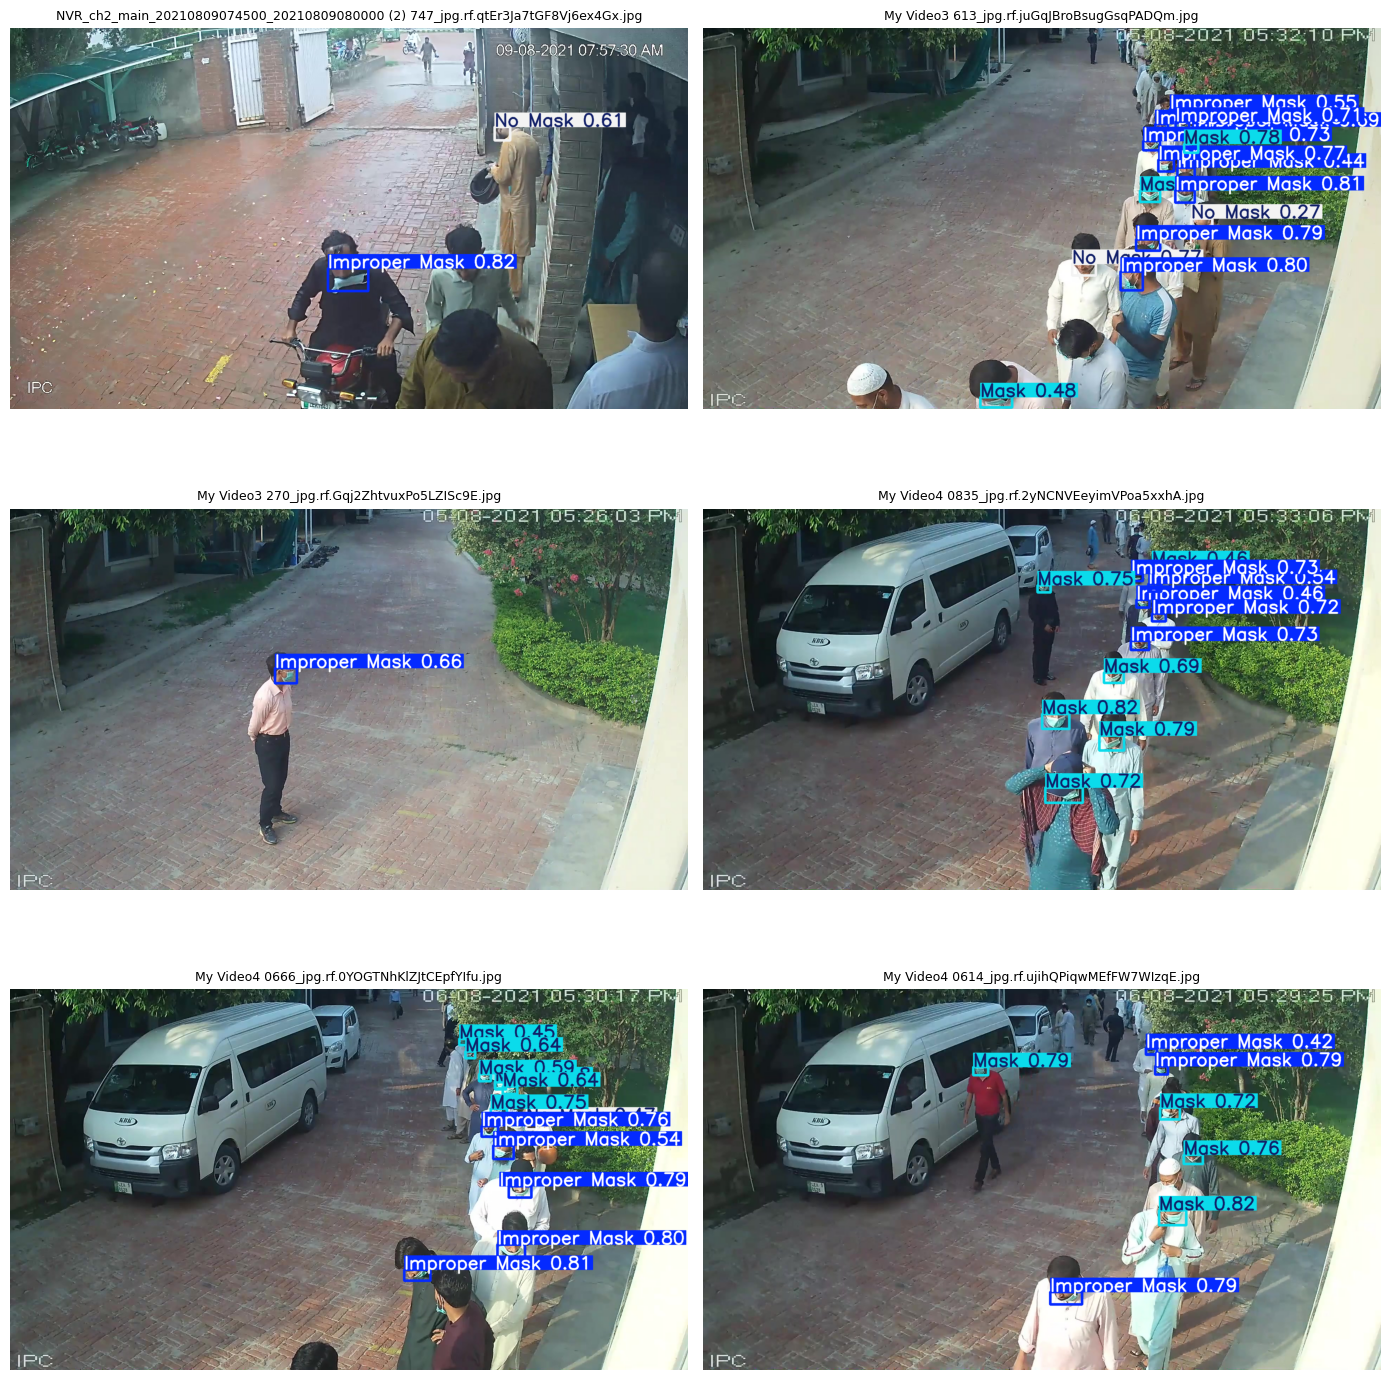

In [8]:
N_SAMPLES = 6
test_dir = DATASET_DIR / "test" / "images"
test_images: list[Path] = []
for ext in ("*.jpg", "*.jpeg", "*.png"):
    test_images.extend(sorted(test_dir.glob(ext)))

samples = random.Random(SEED).sample(test_images, min(N_SAMPLES, len(test_images)))

cols = 2
rows_n = (len(samples) + cols - 1) // cols
fig, axes = plt.subplots(rows_n, cols, figsize=(14, 5 * rows_n))
axes = axes.flatten()
for ax, img_path in zip(axes, samples):
    r = eval_model.predict(str(img_path), conf=0.25, imgsz=640, verbose=False)[0]
    ax.imshow(r.plot()[..., ::-1])
    ax.set_title(img_path.name, fontsize=9)
    ax.axis("off")
for ax in axes[len(samples):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Catatan

Patokan kasar buat face mask detection:

| mAP50 | Verdict |
|---|---|
| ≥ 0.85 | Bagus, siap deploy |
| 0.70 – 0.85 | Lumayan, bisa dipakai dengan post-processing tambahan |
| < 0.70 | Lemah, butuh tuning |

Kalau hasilnya masih kurang:

- Naikin `epochs` (default 50, coba 100).
- Cek confusion matrix — kalau `mask` ↔ `improper_mask` sering ke-tukar, dataset-nya emang ambigu (label "improper" subjektif).
- Cek `args.yaml` di run dir buat liat augmentasi yang aktif.

Buat register ke service: edit entry `face_mask` di [registry.py](../../../src/cctv_insight_ai/models/registry.py).
